# Results Analysis
Bar charts of each metric across pipelines, driven entirely by `results/summary/all_runs.parquet`.

In [1]:
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet('results/summary/all_runs.parquet')
df.head()

,exp_id,dataset,pipeline,stage_cutoffs,total_time_s,cpu_time_s,peak_vram_mb,mean_gpu_util_pct,energy_j,throughput_docs_per_s,timestamp,metric_name,k,value
0,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,precision,1,0.105304
1,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,precision,5,0.058991
2,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,precision,10,0.044191
3,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,ndcg,1,0.105304
4,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,ndcg,5,0.072725


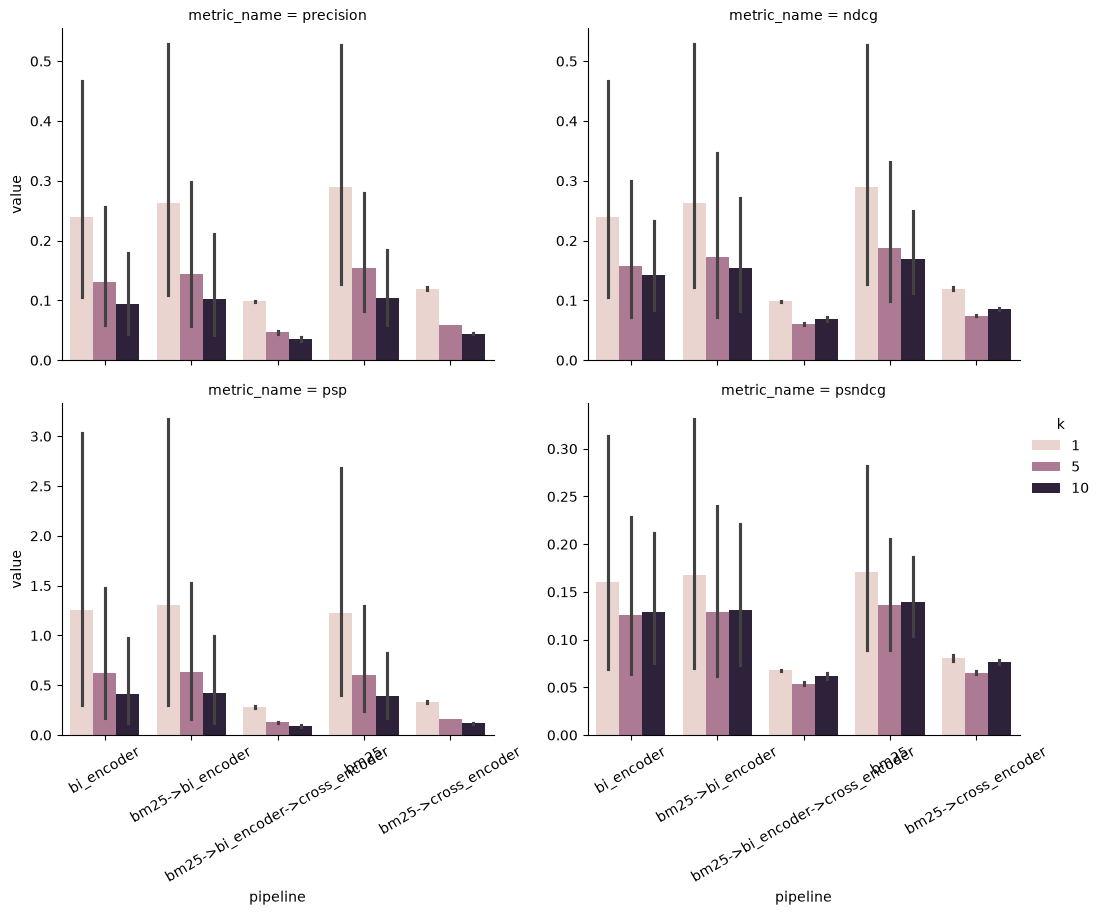

In [2]:
metrics_of_interest = ['precision', 'ndcg', 'psp', 'psndcg']
plot_df = df[df['metric_name'].isin(metrics_of_interest) & df['k'].isin([1, 5, 10])]

g = sns.catplot(
    data=plot_df, x='pipeline', y='value', hue='k', col='metric_name',
    kind='bar', col_wrap=2, height=4, aspect=1.3, sharey=False,
)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30)
g.savefig('reports/figures/03_metrics_by_pipeline.png', dpi=150)
plt.show()

In [3]:
stage_lat = df[['exp_id', 'pipeline', 'stage_cutoffs', 'total_time_s', 'throughput_docs_per_s']].drop_duplicates()
stage_lat.sort_values('total_time_s')

,exp_id,pipeline,stage_cutoffs,total_time_s,throughput_docs_per_s
78,bm25_only,bm25,10,1.729754,2234.421224
91,bm25_only_rag,bm25,10,2.174971,1777.034814
0,biencoder_only,bi_encoder,10,6.550020,590.074499
13,biencoder_only_rag,bi_encoder,10,6.580154,587.372238
26,bm25_bi_1000_100,bm25->bi_encoder,1000>100,8.491720,455.149276
156,wiki10_bm25_only,bm25,10,8.691788,761.178209
39,bm25_bi_1000_100_rag,bm25->bi_encoder,1000>100,8.804066,439.001725
130,wiki10_biencoder_only,bi_encoder,10,11.992433,551.681199
143,wiki10_bm25_bi_1000_100,bm25->bi_encoder,1000>100,19.336946,342.142956
52,bm25_bi_cross_1000_100_10,bm25->bi_encoder->cross_encoder,1000>100>10,454.555294,8.502816
